# PQC Benchmark Analysis
This notebook provides a graphical analysis of benchmarking results for two web servers using different key exchange mechanisms: X25519 and X25519MLKEM768.

## Imports and environment setup
The following libraries are imported to support benchmark analysis and visualization. They are used for tabular data processing, numerical computation, file discovery, path handling, and chart generation.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path
import glob
import math

## Configuration and data preparation
This section defines plotting settings, loads benchmark data, normalizes selected fields, and prepares shared variables used throughout the analysis.

In [3]:
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

CLASSIC_COLOR = '#2166ac'
HYBRID_COLOR  = '#d6604d'
ALPHA = 0.85

FIGURES_DIR = Path('results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

files = sorted(glob.glob('input/benchmark_*.csv'))
assert files, "No CSV files found in results/raw/"
print(f'Found {len(files)} CSV files')

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df['endpoint'] = df['endpoint'].apply(
    lambda x: x.split('/', 1)[-1] if ':' in x else x
)

VARIANTS = df['variant'].unique().tolist()
assert 'classic' in VARIANTS and 'hybrid' in VARIANTS, \
    f"Expected 'classic' and 'hybrid' variants, got: {VARIANTS}"

ENDPOINT_ORDER = (
    df.groupby('endpoint')['size_bytes']
    .median()
    .sort_values()
    .index
    .tolist()
)

def make_label(ep, median_bytes):
    if median_bytes < 1024:
        return f'direct\n({int(median_bytes)} B)'
    elif median_bytes < 1024 * 1024:
        return f'{median_bytes/1024:.0f} KB'
    else:
        return f'{median_bytes/1024/1024:.0f} MB'

median_sizes = df.groupby('endpoint')['size_bytes'].median()
ENDPOINT_LABELS = {
    ep: make_label(ep, median_sizes[ep])
    for ep in ENDPOINT_ORDER
}

x = np.arange(len(ENDPOINT_ORDER))
width = 0.35

print(f'Variants:  {VARIANTS}')
print(f'Endpoints: {ENDPOINT_ORDER}')
print(f'Labels:    {ENDPOINT_LABELS}')
print(f'Total rows: {len(df)}')

Found 7 CSV files
Variants:  ['classic', 'hybrid']
Endpoints: ['api/direct', 'api/payload/1kb', 'api/payload/100kb', 'api/payload/1mb']
Labels:    {'api/direct': 'direct\n(2 B)', 'api/payload/1kb': '1 KB', 'api/payload/100kb': '100 KB', 'api/payload/1mb': '1 MB'}
Total rows: 11200


## ClientHello and ServerHello sizes differences.

Following output shows difference in sizes between classic and hybrid packet sizes for ClientHello and ServerHello during TLS Handshake.

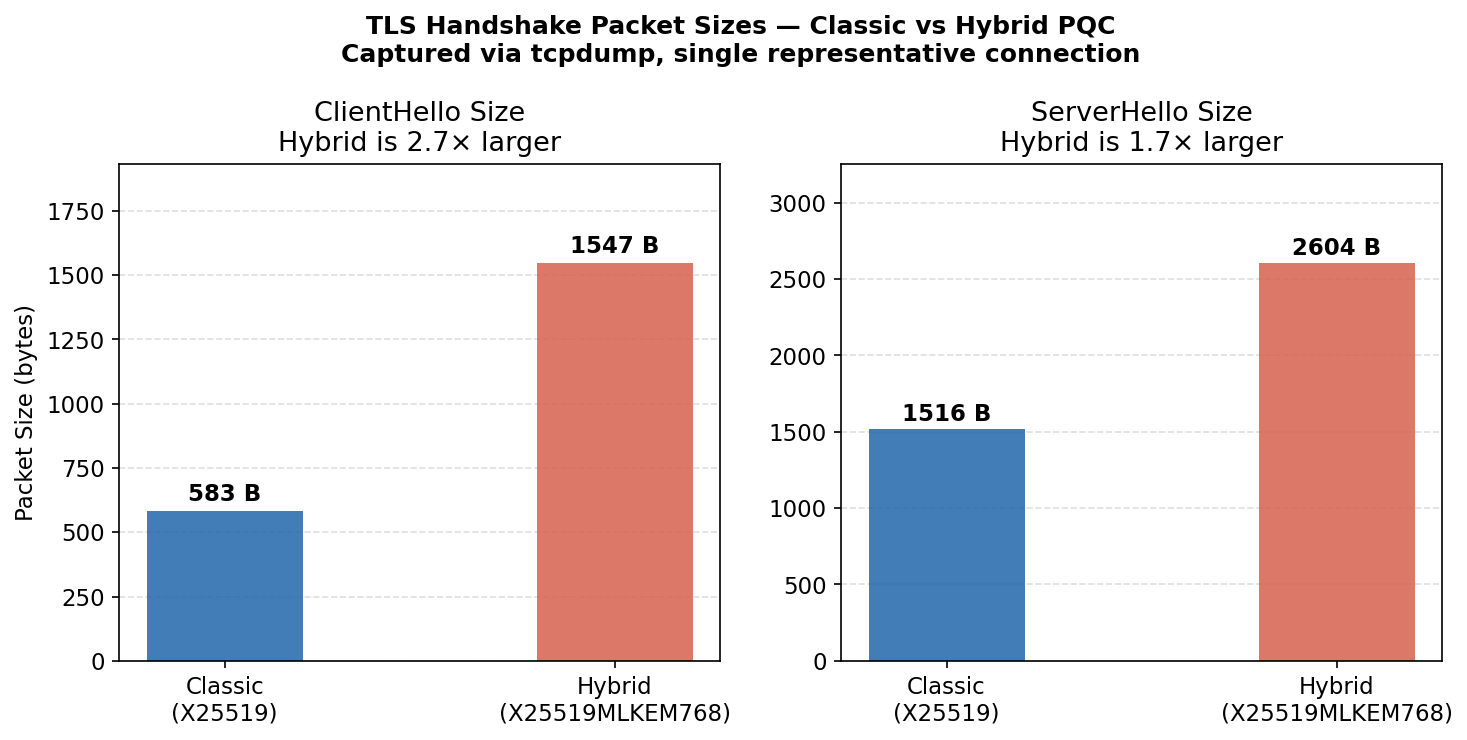

Saved fig9


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

variants  = ['Classic\n(X25519)', 'Hybrid\n(X25519MLKEM768)']
ch_sizes  = [583,  1547]
sh_sizes  = [1516, 2604]

for ax, sizes, title, ylabel in [
    (axes[0], ch_sizes, 'ClientHello Size', 'Packet Size (bytes)'),
    (axes[1], sh_sizes, 'ServerHello Size', ''),
]:
    colors = [CLASSIC_COLOR, HYBRID_COLOR]
    bars = ax.bar(variants, sizes, color=colors, alpha=ALPHA, width=0.4)

    for bar, val in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 20,
                f'{val} B', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    ratio = sizes[1] / sizes[0]
    ax.set_title(f'{title}\nHybrid is {ratio:.1f}× larger')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(sizes) * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

fig.suptitle('TLS Handshake Packet Sizes — Classic vs Hybrid PQC\n'
             'Captured via tcpdump, single representative connection',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig9_packet_sizes.pdf')
plt.show()
print('Saved fig9')